<a href="https://colab.research.google.com/github/nikhitha2007/ML-SKILL/blob/main/07_Auto_MPG_Regression_Scaling_Encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AUTO MPG - LINEAR REGRESSION, SCALING AND ENCODING

1. DATASET LOADED
Dataset shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino



2. DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB

3. STATISTICAL SUMMARY


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000



4. MISSING VALUES
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


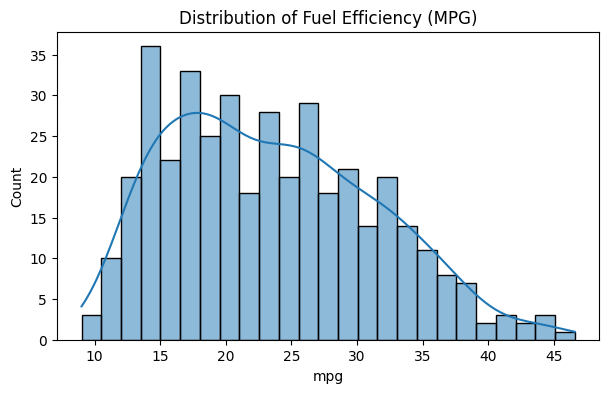

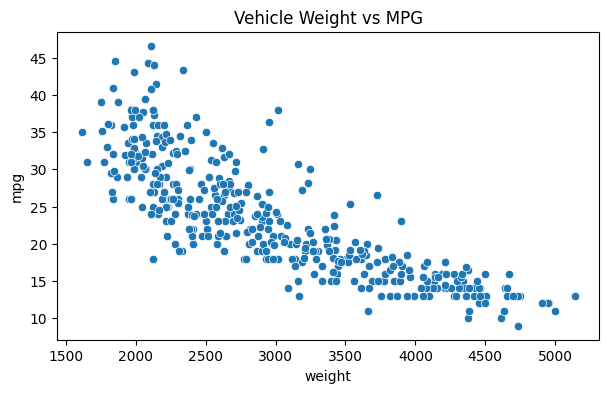

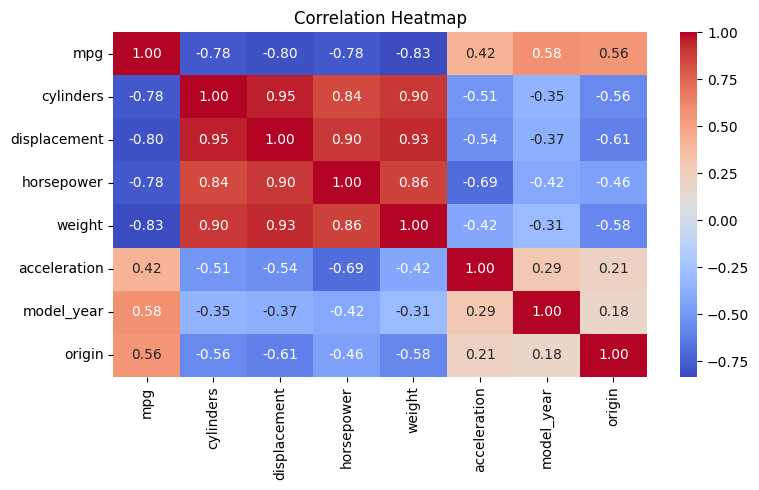


5. TRAINING SAMPLES: 318
TESTING SAMPLES: 80

6. MODEL TRAINED SUCCESSFULLY

7. MODEL EVALUATION
Mean Absolute Error (MAE): 2.288
Mean Squared Error (MSE): 8.339
Root Mean Squared Error (RMSE): 2.888
R2 Score: 0.845


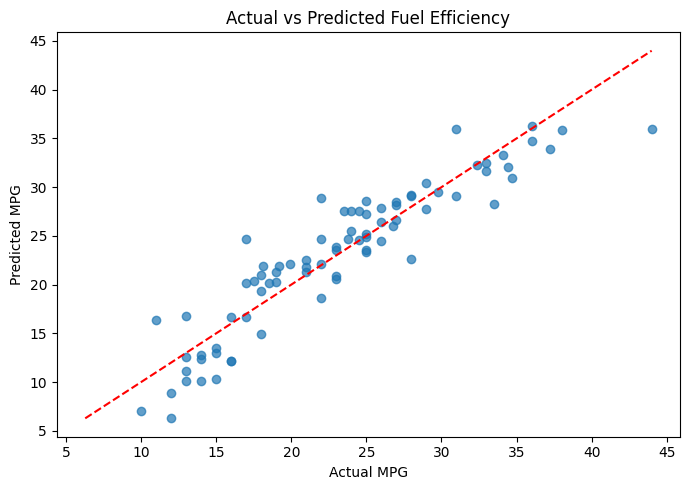


8. SAMPLE PREDICTIONS


,Actual MPG,Predicted MPG,Absolute Error
198,33.0,32.487036,0.512964
396,28.0,29.194007,1.194007
33,19.0,21.246958,2.246958
208,13.0,16.825130,3.825130
93,14.0,12.343166,1.656834
84,27.0,26.578750,0.421250
373,24.0,27.560087,3.560087
94,13.0,10.058870,2.941130
222,17.0,16.636082,0.363918
126,21.0,21.779995,0.779995



9. CONCLUSION
The Auto MPG dataset was explored and prepared for modeling.
Missing numerical values were imputed and scaled.
The origin feature was encoded using one-hot encoding.
Linear regression was evaluated using MAE, RMSE and R2.
Predictions saved to auto_mpg_predictions.csv


In [1]:

# PROGRAM 7: AUTO MPG - LINEAR REGRESSION, SCALING AND ENCODING

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 70)
print("AUTO MPG - LINEAR REGRESSION, SCALING AND ENCODING")
print("=" * 70)

# 2. Load Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

columns = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin", "car_name"
]

df = pd.read_csv(
    url,
    sep=r"\s+",
    names=columns,
    na_values="?",
    quotechar='"'
)

# Clean car names
df["car_name"] = df["car_name"].str.strip()

print("\n1. DATASET LOADED")
print("Dataset shape:", df.shape)
display(df.head())

# 3. Dataset Information
print("\n2. DATASET INFORMATION")
df.info()

print("\n3. STATISTICAL SUMMARY")
display(df.describe())

# 4. Missing Values
print("\n4. MISSING VALUES")
print(df.isnull().sum())

# 5. Exploratory Data Analysis
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="mpg", bins=25, kde=True)
plt.title("Distribution of Fuel Efficiency (MPG)")
plt.show()

plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x="weight", y="mpg")
plt.title("Vehicle Weight vs MPG")
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 6. Feature Selection
# Predict MPG using the other vehicle specifications.
# Car name is excluded because it is a high-cardinality identifier.
X = df.drop(columns=["mpg", "car_name"])
y = df["mpg"]

numeric_features = [
    "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year"
]
categorical_features = ["origin"]

# 7. Preprocessing Pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# 8. Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n5. TRAINING SAMPLES:", len(X_train))
print("TESTING SAMPLES:", len(X_test))

# 9. Build and Train Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)
print("\n6. MODEL TRAINED SUCCESSFULLY")

# 10. Predictions and Evaluation
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n7. MODEL EVALUATION")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R2 Score: {r2:.3f}")

# 11. Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted Fuel Efficiency")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.tight_layout()
plt.show()

# 12. Sample Predictions
results = pd.DataFrame({
    "Actual MPG": y_test,
    "Predicted MPG": y_pred
})
results["Absolute Error"] = abs(
    results["Actual MPG"] - results["Predicted MPG"]
)

print("\n8. SAMPLE PREDICTIONS")
display(results.head(10))

# 13. Save Results
results.to_csv("auto_mpg_predictions.csv", index=False)

print("\n9. CONCLUSION")
print("The Auto MPG dataset was explored and prepared for modeling.")
print("Missing numerical values were imputed and scaled.")
print("The origin feature was encoded using one-hot encoding.")
print("Linear regression was evaluated using MAE, RMSE and R2.")
print("Predictions saved to auto_mpg_predictions.csv")